# Sourmash gather result analysis - weighted_vs_biome plot

> The graph is focusing solely on the average weighted match percentages along with their standard deviations for each biome type. Each biome type is color-coded for clearer visualization.

> The table listed:
    - Accession
    - ref_f_unweighted: The fraction of the metagenome that uniquely matched reference sequence
    - ref_f_weighted: The fraction of total weighted (by multiplicity) k-mers that were identified.
    - Type of metagenome - biome3 
    - % belong to a known host: Indicates the percentage of host contamination - in progress

> The biome3 column contain hierarchical biome information separated by colons (:). The first part ("level 1") appears to describe the general category (e.g., "Host-associated" or "Environmental"), and the second part ("level 2") specifies a more detailed category (e.g., "Mammals", "Human", "Aquatic").

> Group the data by biome type and calculate the average, standard deviation, and count for weighted match percentages. We then create a color map based on the unique biome types

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
data = pd.read_csv('../../data/join_rs220_k21.csv')
len(data)

1901

In [2]:
data.tail()

,accession,ref_f_unweighted,ref_f_weighted,n_matches,biome3
1896,SRR9182862,0.394222,0.658474,56222,Host-associated:Invertebrates:Cnidaria
1897,SRR9182871,0.381782,0.670041,48137,Host-associated:Invertebrates:Cnidaria
1898,SRR9182872,0.376556,0.635570,55954,Host-associated:Invertebrates:Cnidaria
1899,SRR9217436,0.818403,0.837070,324,Host-associated:Human:Digestive system
1900,SRR975540,0.293763,0.478115,2097,Engineered:Lab Synthesis:Genetic cross


In [3]:
data.head()

,accession,ref_f_unweighted,ref_f_weighted,n_matches,biome3
0,DRR014782,0.733621,0.949541,12389,Host-associated:Mammals:Respiratory system
1,DRR014785,0.728105,0.946977,13328,Host-associated:Mammals:Respiratory system
2,DRR019499,0.268765,0.259064,21126,Host-associated:Insecta:Digestive system
3,DRR042462,0.901071,0.965085,3213,Host-associated:Human:Digestive system
4,DRR042463,0.815821,0.937989,4229,Host-associated:Human:Digestive system


/var/folders/s9/2gscp4217xx30p4htg050dx40000gp/T/ipykernel_59447/2273610897.py:63: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout(rect=[0, 0, 0.85, 1])


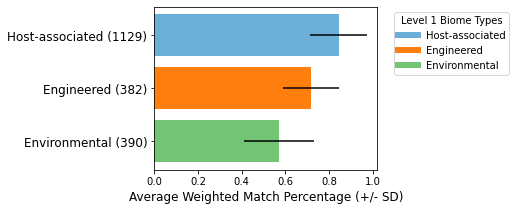

In [4]:
# Extract the level 1 biome from the 'biome3' column
data['level1_biome'] = data['biome3'].apply(lambda x: x.split(':')[0])

# Group the data by the new level 1 biome category
level1_biome_analysis = data.groupby('level1_biome').agg(
    avg_ref_f_weighted=('ref_f_weighted', 'mean'),
    std_ref_f_weighted=('ref_f_weighted', 'std'),
    count=('level1_biome', 'size')
).reset_index()

# Handle missing values for standard deviation
level1_biome_analysis['std_ref_f_weighted'] = level1_biome_analysis['std_ref_f_weighted'].fillna(0)

# Sort by average weighted match percentage
level1_biome_analysis_sorted = level1_biome_analysis.sort_values(
    by='avg_ref_f_weighted',
    ascending=True
)

# Update biome labels to include counts
level1_biome_analysis_sorted['label'] = level1_biome_analysis_sorted.apply(
    lambda x: f"{x['level1_biome']} ({x['count']})", axis=1
)

# ✅ Fixed colors to match previous figure
level1_color_map = {
    'Host-associated': '#6baed6',
    'Environmental': '#74c476',
    'Engineered': '#ff7f0e'
}

# Set up the plotting area
fig, ax = plt.subplots(figsize=(4, 3))

# Plot bars
for _, row in level1_biome_analysis_sorted.iterrows():
    ax.barh(
        row['label'],
        row['avg_ref_f_weighted'],
        xerr=row['std_ref_f_weighted'],
        color=level1_color_map[row['level1_biome']]
    )

ax.set_xlabel('Average Weighted Match Percentage (+/- SD)', fontsize=12)
ax.tick_params(axis='y', labelsize=12)

# Legend in figure order (top → bottom)
legend_handles = [
    plt.Line2D([0], [0],
               color=level1_color_map[biome],
               lw=6,
               label=biome)
    for biome in level1_biome_analysis_sorted['level1_biome'][::-1]
]

ax.legend(
    handles=legend_handles,
    title="Level 1 Biome Types",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

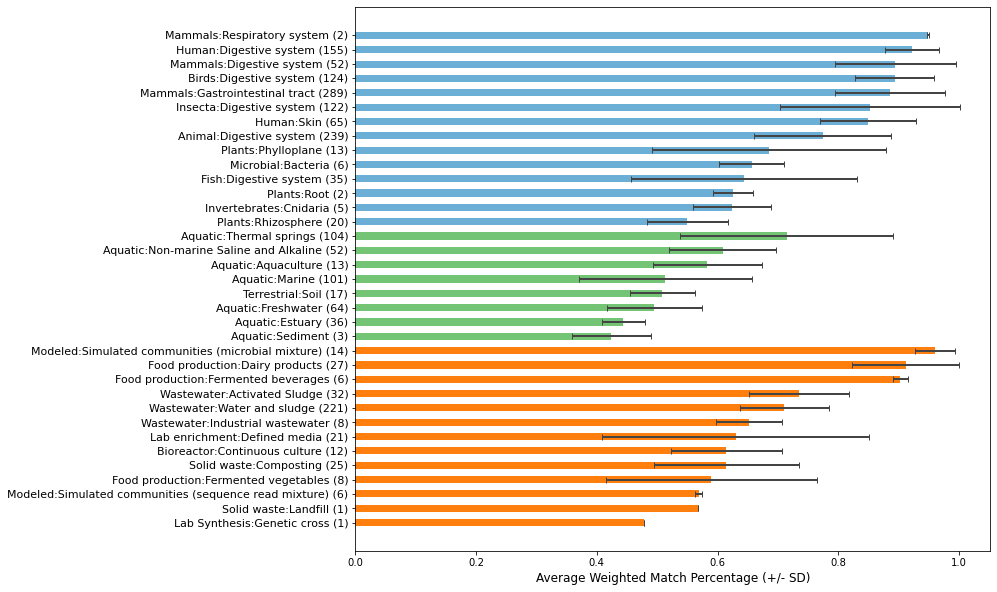

In [5]:
# use better color
import numpy as np
import matplotlib.pyplot as plt

# Extract level-1 biome
data['biome1'] = data['biome3'].str.split(':').str[0]

# Extract shorter biome label (remove level-1 prefix)
data['biome_short'] = data['biome3'].apply(
    lambda x: ':'.join(x.split(':')[1:])
)

# Group by biome3, keep biome1 + short label
biome_analysis = data.groupby(['biome3', 'biome1', 'biome_short']).agg(
    avg_ref_f_weighted=('ref_f_weighted', 'mean'),
    std_ref_f_weighted=('ref_f_weighted', 'std'),
    count=('biome3', 'size')
).reset_index()

# Handle missing SD
biome_analysis['std_ref_f_weighted'] = biome_analysis['std_ref_f_weighted'].fillna(0)

# Sort by biome1 first, then by average value
biome_analysis_sorted = biome_analysis.sort_values(
    by=['biome1', 'avg_ref_f_weighted'],
    ascending=[True, True]
)

# Create shorter labels (no biome1 prefix)
biome_analysis_sorted['label'] = biome_analysis_sorted.apply(
    lambda x: f"{x['biome_short']} ({x['count']})", axis=1
)

# Color mapping
biome1_color_map = {
    'Environmental': '#74c476',
    'Engineered': '#ff7f0e',
    'Host-associated': '#6baed6'
}

biome_analysis_sorted['color'] = biome_analysis_sorted['biome1'].map(biome1_color_map)

# Plot
fig, ax = plt.subplots(figsize=(14, 10))

ax.barh(
    biome_analysis_sorted['label'],
    biome_analysis_sorted['avg_ref_f_weighted'],
    xerr=biome_analysis_sorted['std_ref_f_weighted'],
    color=biome_analysis_sorted['color'],
    height=0.5,
    ecolor='#444444',        # darker gray for visibility
    capsize=3,               # slightly larger caps
    error_kw={'elinewidth': 2}  # thicker SD bars
)

# Labels
ax.set_xlabel('Average Weighted Match Percentage (+/- SD)', fontsize=12)

# Tick sizes (⬅️ increased y-axis font)
ax.tick_params(axis='y', labelsize=11)   # was 9 → now clearer
ax.tick_params(axis='x', labelsize=10)

# Expand plot area (important for long labels)
plt.subplots_adjust(left=0.35, right=0.98)

plt.show()

## plot by Level 3 - total 38

In [6]:
total_biome3_categories = data['biome3'].nunique()
print(total_biome3_categories)

35


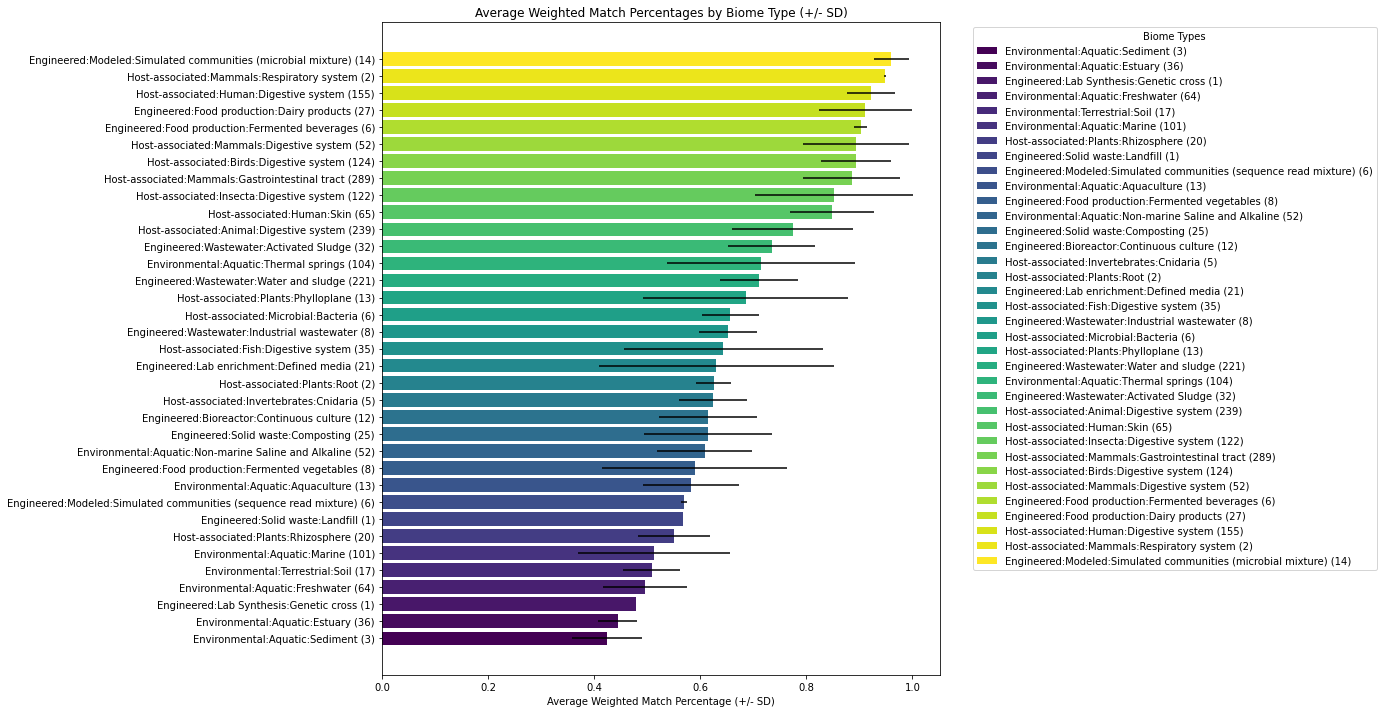

In [7]:
# Group the data by biome type and calculate the average, standard deviation, and count for weighted match percentages
biome_analysis = data.groupby('biome3').agg(
    avg_ref_f_weighted=('ref_f_weighted', 'mean'),
    std_ref_f_weighted=('ref_f_weighted', 'std'),
    count=('biome3', 'size')  # Count the number of entries per biome3
).reset_index()

# Handle missing values for standard deviation
biome_analysis['std_ref_f_weighted'] = biome_analysis['std_ref_f_weighted'].fillna(0)

# Sort the data by average weighted match percentage for visualization
biome_analysis_sorted = biome_analysis.sort_values(by='avg_ref_f_weighted', ascending=True)

# Update biome labels to include counts
biome_analysis_sorted['label'] = biome_analysis_sorted.apply(lambda x: f"{x['biome3']} ({x['count']})", axis=1)

# Create a color map based on the unique biome types
biome_types = biome_analysis_sorted['label'].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(biome_types)))
color_map = dict(zip(biome_types, colors))

# Set up the plotting area
fig, ax = plt.subplots(figsize=(10, 12))

# Plotting with color coding and error bars for standard deviation
biome_legend = {}  # to store legend handles
for biome, color in color_map.items():
    subset = biome_analysis_sorted[biome_analysis_sorted['label'] == biome]
    bars = ax.barh(subset['label'], subset['avg_ref_f_weighted'], xerr=subset['std_ref_f_weighted'], color=color)
    if biome not in biome_legend:  # add to legend only once
        biome_legend[biome] = bars[0]

ax.set_xlabel('Average Weighted Match Percentage (+/- SD)')
ax.set_title('Average Weighted Match Percentages by Biome Type (+/- SD)')
ax.legend(biome_legend.values(), biome_legend.keys(), bbox_to_anchor=(1.05, 1), loc='upper left', title="Biome Types")

plt.show()

In [8]:
# Calculate the count of metagenomes for each biome3 category and sort
biome3_counts = data.groupby('biome3').size().reset_index(name='Number of Samples')
biome3_counts_sorted = biome3_counts.sort_values(by='Number of Samples', ascending=True)

# Display the DataFrame without the index
print(biome3_counts_sorted.to_string(index=False))

                                                          biome3  Number of Samples
                          Engineered:Lab Synthesis:Genetic cross                  1
                                 Engineered:Solid waste:Landfill                  1
                                     Host-associated:Plants:Root                  2
                      Host-associated:Mammals:Respiratory system                  2
                                  Environmental:Aquatic:Sediment                  3
                          Host-associated:Invertebrates:Cnidaria                  5
                              Host-associated:Microbial:Bacteria                  6
                  Engineered:Food production:Fermented beverages                  6
Engineered:Modeled:Simulated communities (sequence read mixture)                  6
                 Engineered:Food production:Fermented vegetables                  8
                     Engineered:Wastewater:Industrial wastewater            

## plot by Level 2 only - total 18

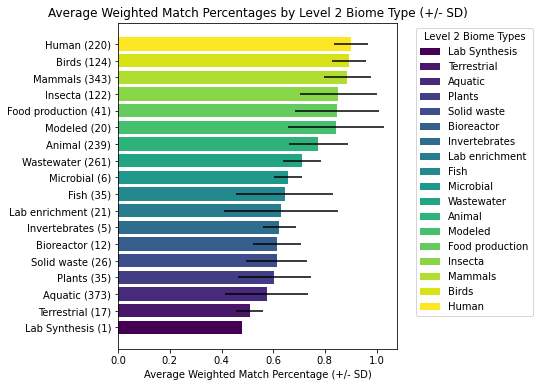

In [9]:
# Extract the level 2 biome from the 'biome3' column
data['level2_biome'] = data['biome3'].apply(lambda x: x.split(':')[1] if len(x.split(':')) > 1 else x)

# Group the data by the new level 2 biome category and calculate the average, standard deviation, and count for weighted match percentages
level2_biome_analysis = data.groupby('level2_biome').agg(
    avg_ref_f_weighted=('ref_f_weighted', 'mean'),
    std_ref_f_weighted=('ref_f_weighted', 'std'),
    count=('level2_biome', 'size')  # Count the number of entries per biome
).reset_index()

# Handle missing values for standard deviation
level2_biome_analysis['std_ref_f_weighted'] = level2_biome_analysis['std_ref_f_weighted'].fillna(0)

# Sort the data by average weighted match percentage for visualization
level2_biome_analysis_sorted = level2_biome_analysis.sort_values(by='avg_ref_f_weighted', ascending=True)

# Update the label to include the count
level2_biome_analysis_sorted['label'] = level2_biome_analysis_sorted.apply(
    lambda x: f"{x['level2_biome']} ({x['count']})", axis=1)

# Create a color map based on the unique level 2 biome types
level2_colors = plt.cm.viridis(np.linspace(0, 1, len(level2_biome_analysis_sorted)))
level2_color_map = dict(zip(level2_biome_analysis_sorted['label'], level2_colors))

# Set up the plotting area
fig, ax = plt.subplots(figsize=(5, 6))

# Plotting with color coding and error bars for standard deviation
for idx, row in level2_biome_analysis_sorted.iterrows():
    ax.barh(row['label'], row['avg_ref_f_weighted'], xerr=row['std_ref_f_weighted'], color=level2_color_map[row['label']])

ax.set_xlabel('Average Weighted Match Percentage (+/- SD)')
ax.set_title('Average Weighted Match Percentages by Level 2 Biome Type (+/- SD)')
ax.legend(level2_biome_analysis_sorted['level2_biome'], title="Level 2 Biome Types", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

In [10]:
total_level2_biome_categories = data['level2_biome'].nunique()
print(total_level2_biome_categories)

18


## plot by Level 1 - total 3

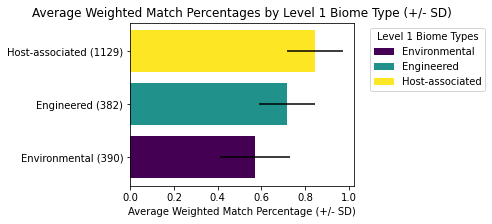

In [11]:
# Extract the level 1 biome from the 'biome3' column
data['level1_biome'] = data['biome3'].apply(lambda x: x.split(':')[0])

# Group the data by the new level 1 biome category and calculate the average, standard deviation, and count for weighted match percentages
level1_biome_analysis = data.groupby('level1_biome').agg(
    avg_ref_f_weighted=('ref_f_weighted', 'mean'),
    std_ref_f_weighted=('ref_f_weighted', 'std'),
    count=('level1_biome', 'size')  # Count the number of entries per biome
).reset_index()

# Handle missing values for standard deviation
level1_biome_analysis['std_ref_f_weighted'] = level1_biome_analysis['std_ref_f_weighted'].fillna(0)

# Sort the data by average weighted match percentage for visualization
level1_biome_analysis_sorted = level1_biome_analysis.sort_values(by='avg_ref_f_weighted', ascending=True)

# Update biome labels to include counts
level1_biome_analysis_sorted['label'] = level1_biome_analysis_sorted.apply(
    lambda x: f"{x['level1_biome']} ({x['count']})", axis=1)

# Create a color map based on the unique level 1 biome types
level1_colors = plt.cm.viridis(np.linspace(0, 1, len(level1_biome_analysis_sorted)))
level1_color_map = dict(zip(level1_biome_analysis_sorted['level1_biome'], level1_colors))

# Set up the plotting area
fig, ax = plt.subplots(figsize=(4, 3))

# Plotting with color coding and error bars for standard deviation
for idx, row in level1_biome_analysis_sorted.iterrows():
    ax.barh(row['label'], row['avg_ref_f_weighted'], xerr=row['std_ref_f_weighted'], color=level1_color_map[row['level1_biome']])

ax.set_xlabel('Average Weighted Match Percentage (+/- SD)')
ax.set_title('Average Weighted Match Percentages by Level 1 Biome Type (+/- SD)')
ax.legend(level1_biome_analysis_sorted['level1_biome'], title="Level 1 Biome Types", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

## plot by Level 1 & 2 - total 17

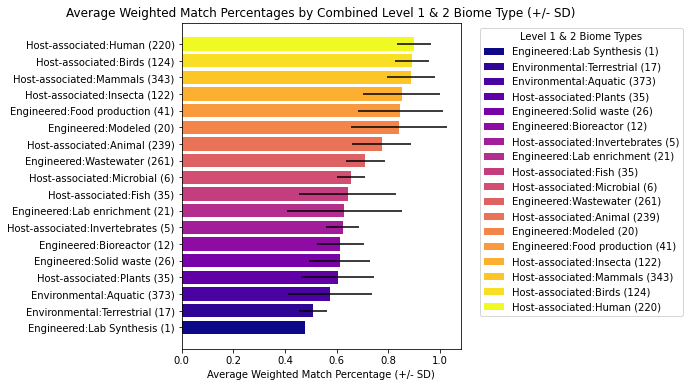

In [12]:
# Combine level 1 and level 2 biome categories into a new column
data['level1_2_biome'] = data['biome3'].apply(lambda x: ':'.join(x.split(':')[:2]))

# Group the data by the combined level 1 and 2 biome category and calculate the average, standard deviation, and count for weighted match percentages
level1_2_biome_analysis = data.groupby('level1_2_biome').agg(
    avg_ref_f_weighted=('ref_f_weighted', 'mean'),
    std_ref_f_weighted=('ref_f_weighted', 'std'),
    count=('level1_2_biome', 'size')  # Count the number of entries per biome
).reset_index()

# Handle missing values for standard deviation
level1_2_biome_analysis['std_ref_f_weighted'] = level1_2_biome_analysis['std_ref_f_weighted'].fillna(0)

# Sort the data by average weighted match percentage for visualization
level1_2_biome_analysis_sorted = level1_2_biome_analysis.sort_values(by='avg_ref_f_weighted', ascending=True)

# Update the label to include the count
level1_2_biome_analysis_sorted['label'] = level1_2_biome_analysis_sorted.apply(
    lambda x: f"{x['level1_2_biome']} ({x['count']})", axis=1)

# Create a color map based on the unique combined level 1 and 2 biome types
level1_2_colors = plt.cm.plasma(np.linspace(0, 1, len(level1_2_biome_analysis_sorted)))
level1_2_color_map = dict(zip(level1_2_biome_analysis_sorted['label'], level1_2_colors))

# Set up the plotting area
fig, ax = plt.subplots(figsize=(5, 6))

# Plotting with color coding and error bars for standard deviation
for idx, row in level1_2_biome_analysis_sorted.iterrows():
    ax.barh(row['label'], row['avg_ref_f_weighted'], xerr=row['std_ref_f_weighted'], color=level1_2_color_map[row['label']])

ax.set_xlabel('Average Weighted Match Percentage (+/- SD)')
ax.set_title('Average Weighted Match Percentages by Combined Level 1 & 2 Biome Type (+/- SD)')
ax.legend(level1_2_color_map.keys(), title="Level 1 & 2 Biome Types", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

In [13]:
total_level1_2_biome_categories = data['level1_2_biome'].nunique()
print(total_level1_2_biome_categories)

18


### Compare all Environmental biomes' mapping rates

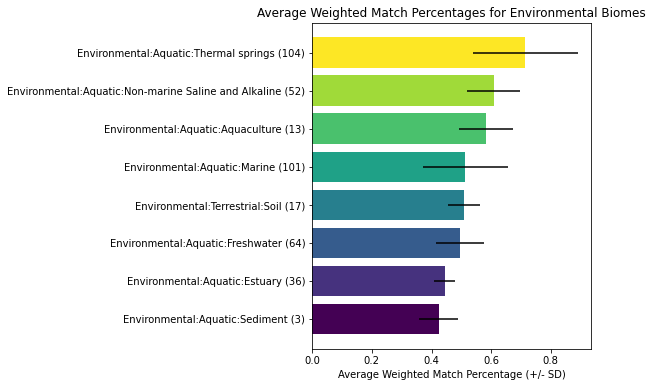

In [14]:
# Filter data to include only 'Environmental' biomes
environmental_biomes = data[data['biome3'].str.startswith('Environmental')]

# Calculate their average weighted mapping percentages, standard deviations, and count
environmental_biome_analysis = environmental_biomes.groupby('biome3').agg(
    avg_ref_f_weighted=('ref_f_weighted', 'mean'),
    std_ref_f_weighted=('ref_f_weighted', 'std'),
    count=('biome3', 'size')
).reset_index()

# Sort by average weighted match percentage for better visualization
environmental_biome_analysis_sorted = environmental_biome_analysis.sort_values(by='avg_ref_f_weighted', ascending=True)

environmental_biome_analysis_sorted['label'] = environmental_biome_analysis_sorted.apply(
    lambda x: f"{x['biome3']} ({x['count']})", axis=1)

# Create a color map based on the unique biome types
colors = plt.cm.viridis(np.linspace(0, 1, len(environmental_biome_analysis_sorted)))

# Plotting
fig, ax = plt.subplots(figsize=(5, 6))
for (idx, row), color in zip(environmental_biome_analysis_sorted.iterrows(), colors):
    bars = ax.barh(row['label'], row['avg_ref_f_weighted'], xerr=row['std_ref_f_weighted'], color=color)

ax.set_xlabel('Average Weighted Match Percentage (+/- SD)')
ax.set_title('Average Weighted Match Percentages for Environmental Biomes')
plt.show()

In [15]:
# Filter data to include only 'Environmental' biomes
environmental_biomes = data[data['biome3'].str.startswith('Environmental')]

# Calculate the number of samples for each Environmental biome
environmental_biome_counts = environmental_biomes['biome3'].value_counts().reset_index()
environmental_biome_counts.columns = ['Biome', 'Number of Samples']

# Print the counts
print(environmental_biome_counts)


                                               Biome  Number of Samples
0              Environmental:Aquatic:Thermal springs                104
1                       Environmental:Aquatic:Marine                101
2                   Environmental:Aquatic:Freshwater                 64
3  Environmental:Aquatic:Non-marine Saline and Al...                 52
4                      Environmental:Aquatic:Estuary                 36
5                     Environmental:Terrestrial:Soil                 17
6                  Environmental:Aquatic:Aquaculture                 13
7                     Environmental:Aquatic:Sediment                  3


In [21]:
# Filter data to include only 'Environmental' biomes
environmental_biomes = data[data['biome3'].str.contains('Environmental')]

# Group the data by biome3 and calculate the average, standard deviation, and count for weighted match percentages
environmental_biome_analysis = environmental_biomes.groupby('biome3').agg(
    avg_ref_f_weighted=('ref_f_weighted', 'mean'),
    std_ref_f_weighted=('ref_f_weighted', 'std'),
    count=('biome3', 'size')  # Count the number of entries per biome3
).reset_index()

# Sort the data by average weighted match percentage for better visualization
environmental_biome_analysis_sorted = environmental_biome_analysis.sort_values(by='avg_ref_f_weighted', ascending=True)

# Save the sorted table to a CSV file without the index
# environmental_biome_analysis_sorted.to_csv('environmental_biome_analysis.csv', index=False)

### Compare all Host-associated biomes' mapping rates

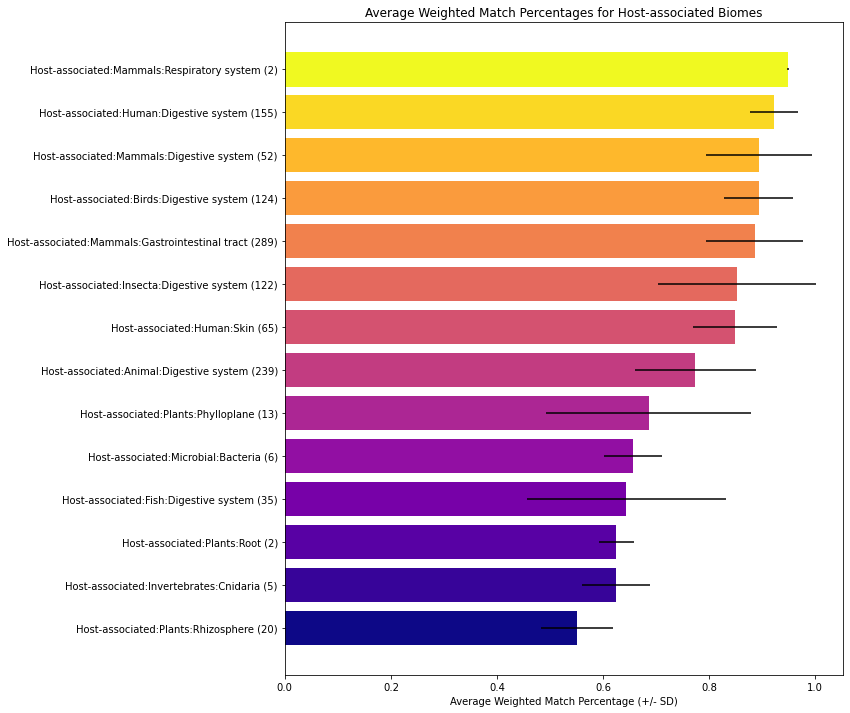

In [17]:
# Filter data to include only 'Host-associated' biomes
host_associated_biomes = data[data['biome3'].str.contains('Host-associated')]

# Group the data by biome3 and calculate the average, standard deviation, and count for weighted match percentages
host_associated_biome_analysis = host_associated_biomes.groupby('biome3').agg(
    avg_ref_f_weighted=('ref_f_weighted', 'mean'),
    std_ref_f_weighted=('ref_f_weighted', 'std'),
    count=('biome3', 'size')  # Count the number of entries per biome3
).reset_index()

# Sort the data by average weighted match percentage for better visualization
host_associated_biome_analysis_sorted = host_associated_biome_analysis.sort_values(by='avg_ref_f_weighted', ascending=True)

# Update biome labels to include counts
host_associated_biome_analysis_sorted['label'] = host_associated_biome_analysis_sorted.apply(
    lambda x: f"{x['biome3']} ({x['count']})", axis=1)

# Create a color map based on the unique Host-associated biome types
colors = plt.cm.plasma(np.linspace(0, 1, len(host_associated_biome_analysis_sorted)))
color_map = dict(zip(host_associated_biome_analysis_sorted['label'], colors))

# Set up the plotting area
fig, ax = plt.subplots(figsize=(10, 12))

# Plotting with color coding and error bars for standard deviation
for idx, row in host_associated_biome_analysis_sorted.iterrows():
    ax.barh(row['label'], row['avg_ref_f_weighted'], xerr=row['std_ref_f_weighted'], color=color_map[row['label']])

ax.set_xlabel('Average Weighted Match Percentage (+/- SD)')
ax.set_title('Average Weighted Match Percentages for Host-associated Biomes')
plt.show()

In [18]:
# Group the data by biome3 and calculate the average, standard deviation, and count for weighted match percentages
host_associated_biome_analysis = host_associated_biomes.groupby('biome3').agg(
    avg_ref_f_weighted=('ref_f_weighted', 'mean'),
    std_ref_f_weighted=('ref_f_weighted', 'std'),
    count=('biome3', 'size')  # Count the number of entries per biome3
).reset_index()

# Sort the data by average weighted match percentage for better visualization
host_associated_biome_analysis_sorted = host_associated_biome_analysis.sort_values(by='avg_ref_f_weighted', ascending=True)

# Print the sorted table without the index
print(host_associated_biome_analysis_sorted.to_string(index=False))

                                        biome3  avg_ref_f_weighted  std_ref_f_weighted  count
            Host-associated:Plants:Rhizosphere            0.550112            0.067673     20
        Host-associated:Invertebrates:Cnidaria            0.623932            0.064455      5
                   Host-associated:Plants:Root            0.625117            0.033177      2
         Host-associated:Fish:Digestive system            0.643759            0.187504     35
            Host-associated:Microbial:Bacteria            0.656517            0.053912      6
            Host-associated:Plants:Phylloplane            0.685624            0.193467     13
       Host-associated:Animal:Digestive system            0.774167            0.113973    239
                    Host-associated:Human:Skin            0.849041            0.079183     65
      Host-associated:Insecta:Digestive system            0.852748            0.149067    122
Host-associated:Mammals:Gastrointestinal tract            0.

In [22]:
# Filter data to include only 'Host-associated' biomes
host_associated_biomes = data[data['biome3'].str.contains('Host-associated')]

# Group the data by biome3 and calculate the average, standard deviation, and count for weighted match percentages
host_associated_biome_analysis = host_associated_biomes.groupby('biome3').agg(
    avg_ref_f_weighted=('ref_f_weighted', 'mean'),
    std_ref_f_weighted=('ref_f_weighted', 'std'),
    count=('biome3', 'size')  # Count the number of entries per biome3
).reset_index()

# Sort the data by average weighted match percentage for better visualization
host_associated_biome_analysis_sorted = host_associated_biome_analysis.sort_values(by='avg_ref_f_weighted', ascending=True)

# Save the sorted table to a CSV file without the index
# host_associated_biome_analysis_sorted.to_csv('host_associated_biome_analysis.csv', index=False)

## compare for "Engineered" sample

In [23]:
# Filter data to include only 'Engineer' biomes
# This assumes 'Engineer' is a keyword in the biome3 column that categorizes certain entries.
# Adjust the filtering term if 'Engineer' is represented differently in your data.
engineer_biomes = data[data['biome3'].str.contains('Engineer')]

# Group the data by biome3 and calculate the average, standard deviation, and count for weighted match percentages
engineer_biome_analysis = engineer_biomes.groupby('biome3').agg(
    avg_ref_f_weighted=('ref_f_weighted', 'mean'),
    std_ref_f_weighted=('ref_f_weighted', 'std'),
    count=('biome3', 'size')  # Count the number of entries per biome3
).reset_index()

# Sort the data by average weighted match percentage for better visualization
engineer_biome_analysis_sorted = engineer_biome_analysis.sort_values(by='avg_ref_f_weighted', ascending=True)

# Save the sorted table to a CSV file without the index
# engineer_biome_analysis_sorted.to_csv('engineer_biome_analysis.csv', index=False)